## Using INSPIRE with graph attention networks (GATs)

INSPIRE provides two integrative analyses options: one based on graph attention networks (GATs) and the other on lightweight graph convolutional networks (LGCNs). For tissue sections profiled using low-resolution platforms such as Visium or ST, we recommend employing the graph attention network variant of INSPIRE to leverage the attention mechanism for improved modeling accuracy. For high-resolution datasets, the lightweight graph convolutional network variant is recommended, as it provides enhanced computational efficiency and scalability for large-scale analyses.

We use the integrative analysis of human DLPFC Visium sections as an example to provide **step-by-step instructions for applying INSPIRE with graph attention networks (GATs)**.

### Import packages

In [1]:
import numpy as np
import scanpy as sc
import umap
import INSPIRE
import warnings
warnings.filterwarnings("ignore")

### Load data

The input to INSPIRE consists of raw gene expression count matrices and spatial coordinate matrices derived from multiple tissue sections, with each section represented as an individual AnnData object. Specifically, for each tissue section, the raw count matrix is stored in adata.X, and the spatial coordinates of the spatial spots are stored in adata.obsm["spatial"].

The example Visium tissue sections used in this tutorial can be downloaded from [this link](https://drive.google.com/drive/folders/1viKSyC-KgkfEH481SLB-JKP4FThZtmLA?usp=sharing).

In [2]:
data_dir = "/gpfs/gibbs/pi/zhao/jz874/project/jiazhao/inspire_revision/tutorials/example_analyses/example_GAT_data"
adata_1 = sc.read_h5ad(data_dir + "/adata_1.h5ad")
adata_2 = sc.read_h5ad(data_dir + "/adata_2.h5ad")
adata_3 = sc.read_h5ad(data_dir + "/adata_3.h5ad")
adata_4 = sc.read_h5ad(data_dir + "/adata_4.h5ad")

adata_st_list = [adata_1, adata_2, adata_3, adata_4]

### Data preprocessing

INSPIRE uses a standard pipline adopted by Seurat and Scanpy to select highly variable genes as input features for data interpretation. In addition, it organizes the spatial positioning of multiple tissue sections to facilitate their joint visualization. Parameters in the INSPIRE.utils.preprocess function include: num_hvg, min_genes_qc, min_cell_qc, and spot_size. INSPIRE uses the intersection of highly variable genes across all sections as features for data modeling. By default, num_hvgs is set to 6,000. We recommend selecting approximately 2,000 to 3,000 shared highly variable genes to perform integrative analyses with INSPIRE. Users can customize quality control thresholds by adjusting min_genes_qc and min_cell_qc. Setting both parameters to 50 generally performs well for Visium datasets. The spot_size parameter is used only for visualization purposes and determines the size of each spot in the generated plots.

Finding highly variable genes...
shape of adata 0 before quality control:  (3611, 33525)
shape of adata 0 after quality control:  (3611, 13067)
shape of adata 1 before quality control:  (3635, 33525)
shape of adata 1 after quality control:  (3635, 13955)
shape of adata 2 before quality control:  (3566, 33525)
shape of adata 2 after quality control:  (3566, 12430)
shape of adata 3 before quality control:  (3431, 33525)
shape of adata 3 after quality control:  (3431, 12564)
Find 1857 shared highly variable genes among datasets.
Concatenate datasets as a full anndata for better visualization...


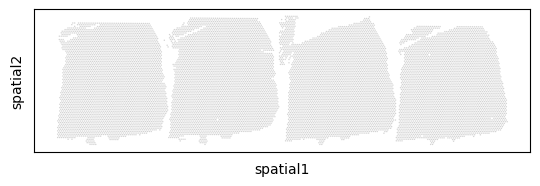

Store counts and library sizes for Poisson modeling...
Normalize data...


In [3]:
adata_st_list, adata_full = INSPIRE.utils.preprocess(adata_st_list=adata_st_list,
                                                     num_hvgs=6000,
                                                     min_genes_qc=50,
                                                     min_cells_qc=50,
                                                     spot_size=100)

### Build spaital graph

INSPIRE constructs a spatial neighbor graph among spots to account for spatial dependencies within each tissue section. When using the graph attention network (GAT) variant, this graph is generated via the INSPIRE.utils.build_graph_GAT function, which takes adata_st_list as input. For low-resolution tissue sections, the function first calculates the minimum distance between adjacent spots within each section and then multiplies this value by a scaling factor, rad_coef, to determine the radius cutoff for defining spatial neighbors. In practice, we set rad_coef to 1.1, which reliably captures natural neighborhood structures in Visium and ST datasets.

In [4]:
adata_st_list = INSPIRE.utils.build_graph_GAT(adata_st_list=adata_st_list, 
                                              rad_coef=1.1)

Start building graphs...
Calculate radius cutoff based on 'rad_coef' and mininal distance between spots/cells within a dataset...
Radius for graph connection is 150.7000.
Build graphs for GAT networks
5.8261 neighbors per cell on average.
5.8140 neighbors per cell on average.
5.8015 neighbors per cell on average.
5.8193 neighbors per cell on average.


### Run INSPIRE model

The computational model for the GAT variant of INSPIRE is constructed using the INSPIRE.model.Model_GAT function, which takes adata_st_list as input. Two key parameters for this function are n_spatial_factors and n_training_steps. The parameter n_spatial_factors determines the number of spatial factors to be inferred, and its value should be chosen based on the complexity of the tissue under analysis. As general guidelines, we recommend setting n_spatial_factors = 20 for regional tissue analysis, n_spatial_factors = 40 for whole-organ analyses, and n_spatial_factors = 60 for whole-organism analyses. The n_training_steps parameter specifies the total number of training iterations. A default setting of n_training_steps = 10,000 typically yields robust results, while increasing it to 20,000 may be beneficial when modeling with a large number of spatial factors.

In [5]:
model = INSPIRE.model.Model_GAT(adata_st_list=adata_st_list,
                                n_spatial_factors=20,
                                n_training_steps=10000,
                               )

After constructing the computational model, training is performed using the model.train function.

In [6]:
model.train()

  0%|          | 2/10000 [00:00<42:58,  3.88it/s]  

Step: 0, d_loss: 4.1890, Loss: 6191.5420, recon_loss: 5737.2090, fe_loss: 153.9308, geom_loss: 1659.0681, beta_loss: 265.5975, gan_loss: 1.6235


  5%|▌         | 502/10000 [01:11<22:31,  7.03it/s]

Step: 500, d_loss: 2.7276, Loss: 4500.6455, recon_loss: 4073.2205, fe_loss: 94.8756, geom_loss: 572.6364, beta_loss: 316.4294, gan_loss: 4.6677


 10%|█         | 1002/10000 [02:22<21:23,  7.01it/s]

...

 90%|█████████ | 9002/10000 [21:24<02:22,  7.00it/s]

Step: 9000, d_loss: 1.1445, Loss: 1755.2981, recon_loss: 1402.1340, fe_loss: 92.9919, geom_loss: 509.8484, beta_loss: 241.4175, gan_loss: 8.5576


 95%|█████████▌| 9502/10000 [22:36<01:11,  7.00it/s]

Step: 9500, d_loss: 0.9016, Loss: 1752.5907, recon_loss: 1399.8112, fe_loss: 92.9360, geom_loss: 547.9695, beta_loss: 241.2215, gan_loss: 7.6627


100%|██████████| 10000/10000 [23:47<00:00,  7.01it/s]


### Access spot representations, proportions of spatial factors in spots, and gene loading matrix

After training the model, INSPIRE infers latent representations of spatial spots, spatial factors, and gene loadings using the model.eval function. This function returns two main outputs: adata_full and basis_df. The inferred latent representations of spatial spots are stored in adata_full.obsm['latent'], while the metadata indicating the section origin of each spot is saved in adata_full.obs. The spatial factor values assigned to individual spots are also stored in adata_full.obs, where adata_full.obs["Proportion of spatial factor i"] contains the proportion values corresponding to spatial factor i across all analyzed spots. The inferred gene loading matrix, shared across sections, is saved in basis_df, which is a data frame with spatial factors as rows and genes as columns.

In [7]:
adata_full, basis_df = model.eval(adata_full)
basis = np.array(basis_df.values)

Add cell/spot proportions of spatial factors into adata_full.obs...
Add cell/spot latent representations into adata_full.obsm['latent']...


In [8]:
basis_df

,AACS,AAK1,AASDHPPT,ABCA2,ABCB1,ABHD13,ABHD17B,ABI1,AC004158.1,AC005944.1,...,ZNF667,ZNF682,ZNF684,ZNF74,ZNF92,ZNHIT6,ZNRD1,ZSCAN29,ZSWIM6,ZYG11B
0,0.000526,0.000810,0.000627,0.000590,0.000120,0.000428,0.000588,0.000421,0.000220,0.000249,...,0.000804,0.000497,0.000120,0.000200,0.000612,0.000390,0.000191,0.000216,0.000407,0.000836
1,0.000685,0.000663,0.000556,0.000289,0.000380,0.000325,0.000303,0.000451,0.000221,0.000315,...,0.000441,0.000174,0.000114,0.000232,0.000268,0.000388,0.000537,0.000194,0.000270,0.000654
2,0.000371,0.000844,0.000643,0.000384,0.000317,0.000490,0.000293,0.000436,0.000208,0.001974,...,0.000531,0.000536,0.000201,0.000373,0.000305,0.000675,0.000355,0.000523,0.000327,0.000544
3,0.000720,0.000713,0.000554,0.000327,0.000420,0.000436,0.000335,0.000439,0.000181,0.000298,...,0.000360,0.000182,0.000311,0.000436,0.000277,0.000324,0.000349,0.000259,0.000289,0.000735
4,0.000381,0.000567,0.000469,0.000466,0.000215,0.000748,0.000426,0.000458,0.000299,0.000328,...,0.000485,0.000479,0.000502,0.000464,0.000315,0.000513,0.000416,0.000386,0.000455,0.000759
5,0.000469,0.000535,0.000513,0.000553,0.000521,0.000521,0.000870,0.000236,0.001019,0.000120,...,0.000211,0.000237,0.000217,0.000564,0.000430,0.000201,0.000517,0.000258,0.000235,0.000671
6,0.000763,0.000925,0.000389,0.000365,0.000277,0.000298,0.000484,0.000429,0.000122,0.000332,...,0.000428,0.000267,0.000309,0.000499,0.000224,0.000424,0.000647,0.000196,0.000286,0.000681
7,0.000607,0.001029,0.000713,0.000286,0.000361,0.000394,0.000481,0.000294,0.000321,0.000460,...,0.000377,0.000416,0.000336,0.000290,0.000283,0.000395,0.000174,0.000303,0.000286,0.000772
8,0.000580,0.000797,0.000717,0.000386,0.000752,0.000401,0.000321,0.000601,0.000175,0.001562,...,0.000329,0.000167,0.000076,0.000445,0.000173,0.000405,0.000429,0.000395,0.000389,0.000667
9,0.000575,0.000747,0.000579,0.000289,0.000396,0.000215,0.000461,0.000386,0.000132,0.001125,...,0.000377,0.000325,0.000187,0.000117,0.000615,0.000408,0.000349,0.000517,0.000259,0.000735


### Spatial distributions of spatial factors in tissues

The proportion values corresponding to spatial factors across all analyzed spots are stored in adata_full.obs. These spatial patterns can be visualized using the sc.pl.spatial function from the Scanpy pipeline. The spot_size parameter controls the size of each spatial spot in the resulting plots.

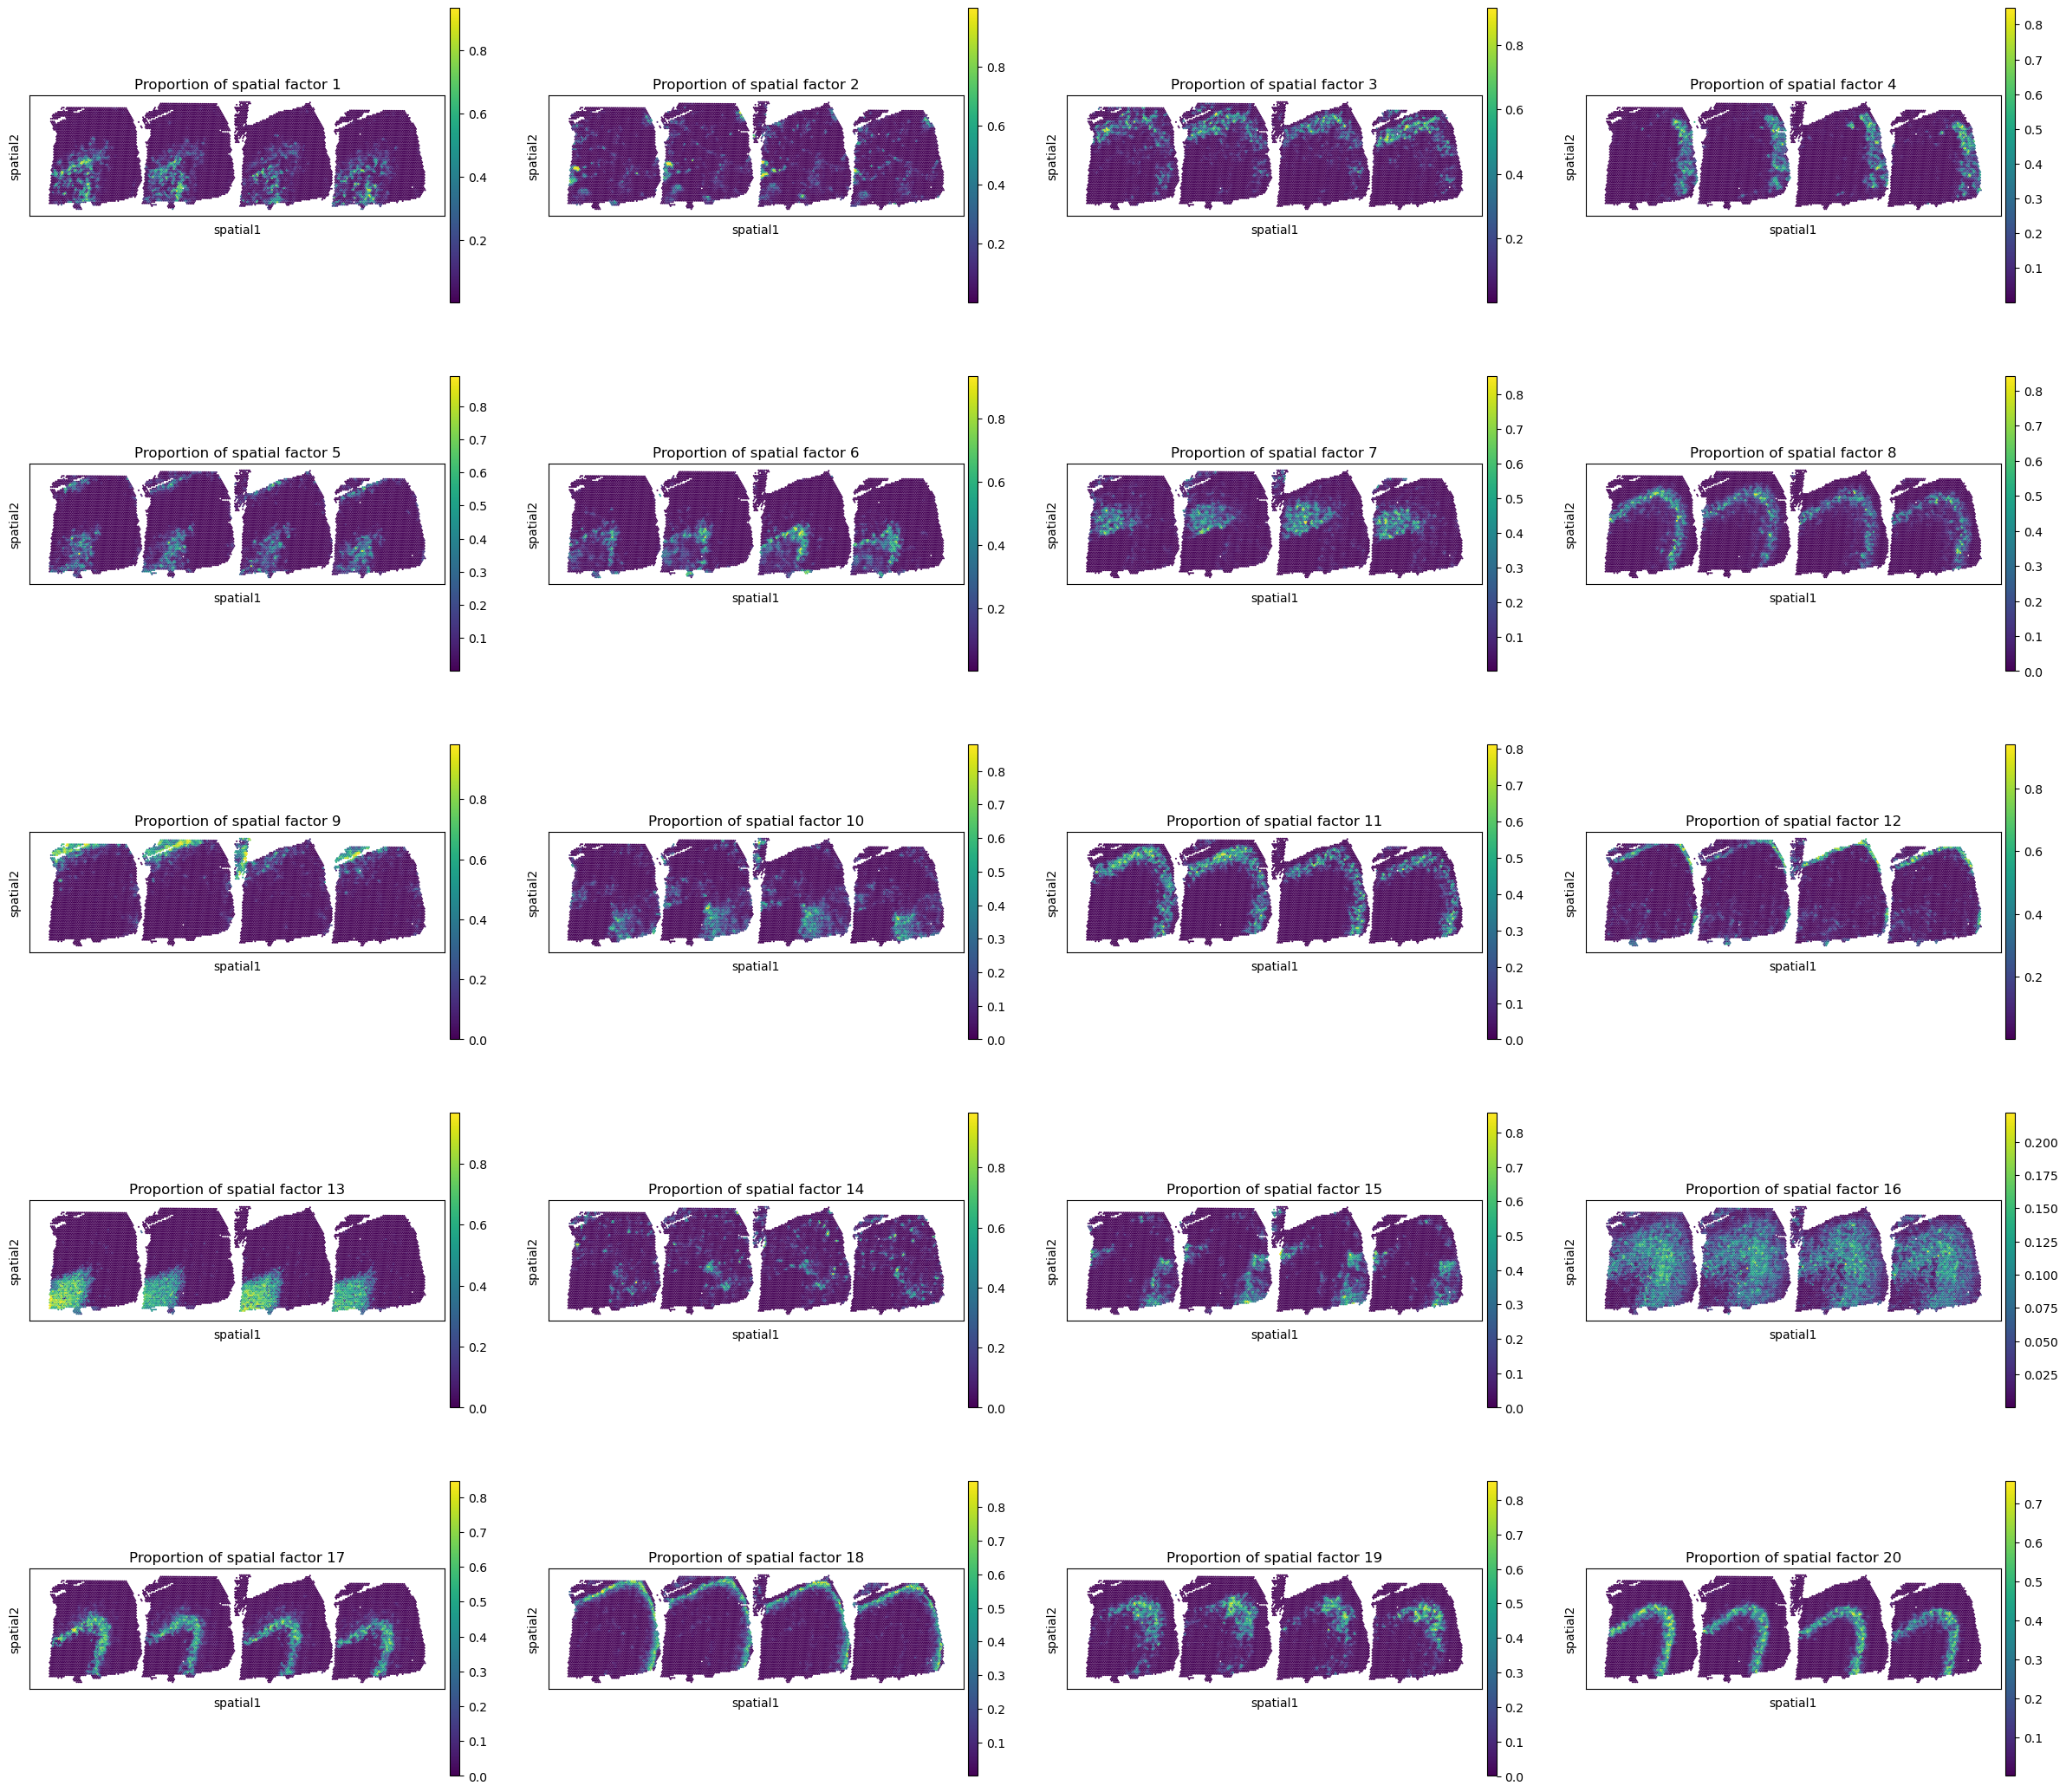

In [9]:
sc.pl.spatial(adata_full, color=["Proportion of spatial factor "+str(i+1) for i in range(20)], spot_size=150.)

### Spot representations and spatial domain identification

To visualize the spot representations learned by INSPIRE, we employ UMAP plots. The UMAP embedding is generated by first constructing a UMAP model using umap.UMAP, and then transforming the spot representations into two-dimensional coordinates using the fit_transform function from the umap package.

In [10]:
# calculate 2D UMAP coordinate of spots based on INSPIRE's learned spot representations.
reducer = umap.UMAP(n_neighbors=30,
                    n_components=2,
                    metric="correlation",
                    n_epochs=None,
                    learning_rate=1.0,
                    min_dist=0.3,
                    spread=1.0,
                    set_op_mix_ratio=1.0,
                    local_connectivity=1,
                    repulsion_strength=1,
                    negative_sample_rate=5,
                    a=None,
                    b=None,
                    random_state=1234,
                    metric_kwds=None,
                    angular_rp_forest=False,
                    verbose=True)
embedding = reducer.fit_transform(adata_full.obsm['latent'])
adata_full.obsm["X_umap"] = embedding
adata_full.obs["slice"] = adata_full.obs["slice"].values.astype(str)

UMAP(angular_rp_forest=True, local_connectivity=1, metric='correlation', min_dist=0.3, n_neighbors=30, random_state=1234, repulsion_strength=1, verbose=True)
Wed May 28 19:41:41 2025 Construct fuzzy simplicial set
Wed May 28 19:41:41 2025 Finding Nearest Neighbors
Wed May 28 19:41:41 2025 Building RP forest with 11 trees
Wed May 28 19:41:44 2025 NN descent for 14 iterations
	 1  /  14
	 2  /  14
	Stopping threshold met -- exiting after 2 iterations
Wed May 28 19:41:52 2025 Finished Nearest Neighbor Search
Wed May 28 19:41:54 2025 Construct embedding


Epochs completed:   0%|            0/200 [00:00]

	completed  0  /  200 epochs
	completed  20  /  200 epochs
	completed  40  /  200 epochs
	completed  60  /  200 epochs
	completed  80  /  200 epochs
	completed  100  /  200 epochs
	completed  120  /  200 epochs
	completed  140  /  200 epochs
	completed  160  /  200 epochs
	completed  180  /  200 epochs
Wed May 28 19:42:07 2025 Finished embedding


For visualizing UMAP plots, we utilizes the sc.pl.umap function from the Scanpy pipeline.

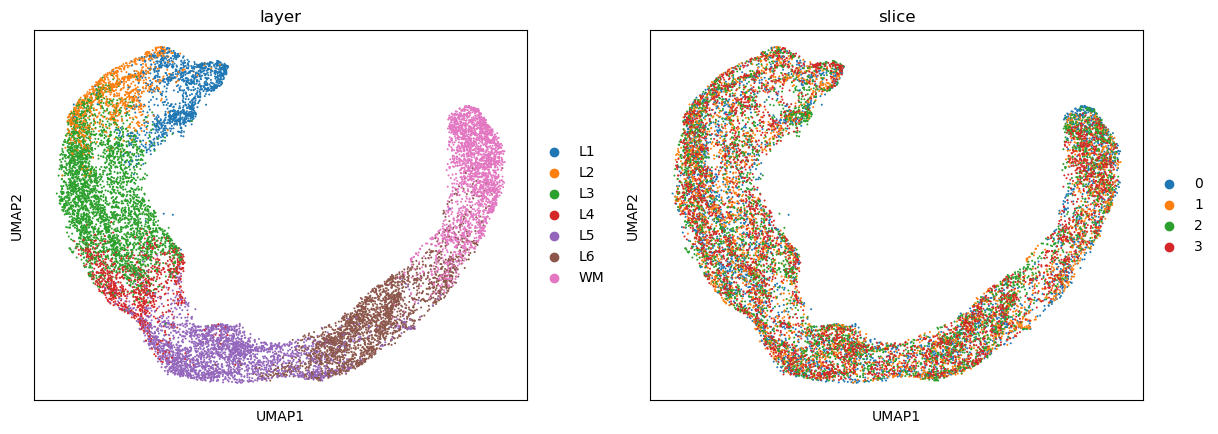

In [11]:
sc.pl.umap(adata_full, color=["layer", "slice"])

The learned spot representations facilitate the identification of spatial domains. In this example, given prior knowledge of the number of ground-truth spatial regions, we apply a Gaussian Mixture Model, as implemented in the sklearn package, to perform clustering.

In [12]:
from sklearn.mixture import GaussianMixture
np.random.seed(1234)
gm = GaussianMixture(n_components=7, covariance_type='tied', init_params='kmeans')
y = gm.fit_predict(adata_full.obsm['latent'], y=None)
adata_full.obs["GM"] = y

Spatial domain assignments are visualized on both the UMAP embedding and the spatial coordinates of the spots using the sc.pl.umap and sc.pl.spatial functions from the Scanpy pipeline, respectively.

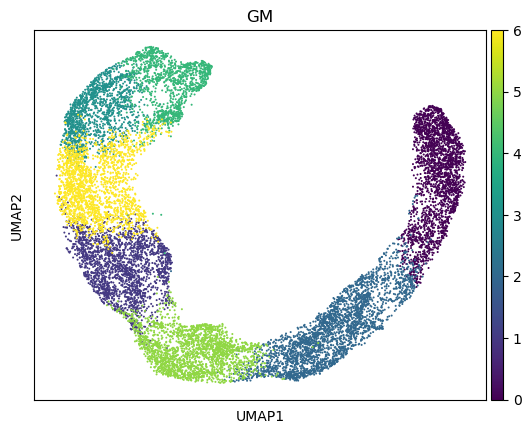

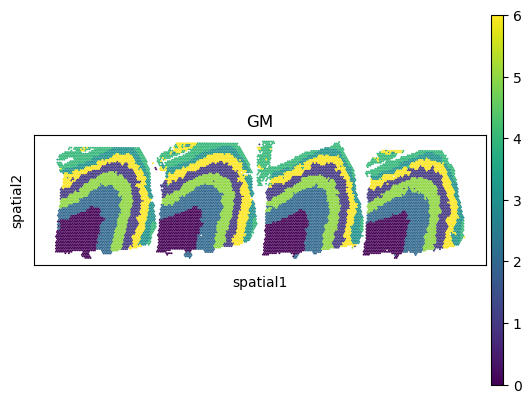

In [13]:
sc.pl.umap(adata_full, color=["GM"])
sc.pl.spatial(adata_full, color=["GM"], spot_size=150.)

Finally, we save the results from INSPIRE.

In [14]:
res_path = "/gpfs/gibbs/pi/zhao/jz874/project/jiazhao/inspire_revision/tutorials/example_analyses/example_GAT_data"
adata_full.write(res_path + "/adata_full_inspire.h5ad")
basis_df.to_csv(res_path + "/basis_df_inspire.csv")